In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

path = '../../data-wrangling/preprocessing/instagram/2025-party-votes-instagram.csv'

df = pd.read_csv(path)

# Make sure the main numeric columns are numeric
numeric_cols = ['Stemmetal', 'Follower Count', 'Number of Posts']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Create a "has_instagram" dummy: 1 if we have follower data, 0 otherwise
df['has_instagram'] = df['Follower Count'].notna().astype(int)

# For modelling, replace missing followers/posts with 0
df['followers'] = df['Follower Count'].fillna(0)
df['posts'] = df['Number of Posts'].fillna(0)
df['votes'] = df['Stemmetal']

# Safety: if votes has any missing, drop those rows (no meaningful outcome)
df = df.dropna(subset=['votes']).copy()

# ============= CREATE LOG(+1) VARIABLES =============

# +1 so that 0 followers / 0 posts become log(1) = 0 (keeps rows with no Instagram)
df['log_votes'] = np.log(df['votes'] + 1)
df['log_followers'] = np.log(df['followers'] + 1)
df['log_posts'] = np.log(df['posts'] + 1)

print("Check transformed columns:")
print(df[['votes', 'followers', 'posts', 'log_votes', 'log_followers', 'log_posts']].head(), "\n")

# ============= CORRELATIONS =============

print("Correlation matrix (raw variables):")
print(df[['votes', 'followers', 'posts']].corr(), "\n")

print("Correlation matrix (log(+1) variables):")
print(df[['log_votes', 'log_followers', 'log_posts']].corr(), "\n")


# ============= HELPER TO RUN LinearRegression =============

def run_linreg(y, X, label=""):
    """
    Fit a scikit-learn LinearRegression model on all data in X, y.
    Prints intercept, coefficients and R², and returns the fitted model.
    """
    model = LinearRegression()
    model.fit(X, y)

    y_pred = model.predict(X)
    r2 = r2_score(y, y_pred)

    print("\n" + "=" * 60)
    print(label)
    print("=" * 60)
    print("Intercept:", model.intercept_)
    print("Coefficients (in order of columns):")
    for name, coef in zip(X.columns, model.coef_):
        print(f"  {name}: {coef:.4f}")
    print(f"R² (on full dataset): {r2:.3f}")

    return model


# ============= MODELS =============

# Model 1: raw levels
X1 = df[['followers', 'posts']]
y1 = df['votes']
m1 = run_linreg(
    y=y1,
    X=X1,
    label="Model 1: votes ~ followers + posts (raw, LinearRegression)"
)

# Model 2: log-log (handles skew and diminishing returns)
X2 = df[['log_followers', 'log_posts']]
y2 = df['log_votes']
m2 = run_linreg(
    y=y2,
    X=X2,
    label="Model 2: log(votes+1) ~ log(followers+1) + log(posts+1) (LinearRegression)"
)

# Model 3: log-log + 'has_instagram' dummy
X3 = df[['log_followers', 'log_posts', 'has_instagram']]
y3 = df['log_votes']
m3 = run_linreg(
    y=y3,
    X=X3,
    label="Model 3: log(votes+1) ~ log(followers+1) + log(posts+1) + has_instagram (LinearRegression)"
)


Check transformed columns:
   votes  followers   posts  log_votes  log_followers  log_posts
0   6608    25700.0  1975.0   8.796188      10.154285   7.588830
1     22      692.0    66.0   3.135494       6.541030   4.204693
2     17       25.0    30.0   2.890372       3.258097   3.433987
3    174        0.0     0.0   5.164786       0.000000   0.000000
4   1333    10800.0   655.0   7.195937       9.287394   6.486161 

Correlation matrix (raw variables):
              votes  followers     posts
votes      1.000000   0.752924  0.806655
followers  0.752924   1.000000  0.848228
posts      0.806655   0.848228  1.000000 

Correlation matrix (log(+1) variables):
               log_votes  log_followers  log_posts
log_votes       1.000000       0.801071   0.813580
log_followers   0.801071       1.000000   0.982875
log_posts       0.813580       0.982875   1.000000 


Model 1: votes ~ followers + posts (raw, LinearRegression)
Intercept: -762.9650781514229
Coefficients (in order of columns):
  follo

Across the three linear regression models, Instagram activity shows a limited and uneven relationship with electoral performance. The raw model (Model 1) explains 66.8% of the variation in votes, with posting frequency showing a positive association but follower count contributing very little. After applying log-transformations (Model 2), the explanatory power remains similar (R² = 0.662), but both followers and posts become weak predictors, indicating that simple scale effects do not reliably explain vote totals. The extended model including Instagram presence (Model 3) performs best (R² = 0.847), yet the coefficient for followers remains near zero and posts only become meaningful among parties that already use Instagram. The strongest factor in this model is the binary “has_instagram” variable, suggesting that the key distinction is whether a party is present on Instagram at all, rather than how many followers it has or how often it posts. Overall, Instagram presence matters, but follower count does not predict votes, and posting activity provides only modest predictive value.

Instagram activity provides some information about electoral performance, particularly whether a party has an Instagram presence at all. However, neither follower count nor posting frequency reliably predicts how many votes a party will receive. Predictive models trained on Instagram data show unstable performance and do not generalize well. Therefore, Instagram metrics cannot be used to accurately predict election results.

In [2]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

def evaluate(X, y, label=""):
    model = LinearRegression()
    model.fit(X, y)

    # R² on full dataset
    y_pred = model.predict(X)
    r2_full = r2_score(y, y_pred)

    # 5-fold CV
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X, y, scoring='r2', cv=kf)

    print("\n" + "="*70)
    print(label)
    print("="*70)
    print(f"n = {len(X)}")
    print("Intercept:", model.intercept_)
    print("Coefficients:", dict(zip(X.columns, model.coef_)))
    print(f"R² (full dataset): {r2_full:.3f}")
    print("CV R²:", cv_scores)
    print("Mean CV R²:", cv_scores.mean())
    print("="*70)

    return cv_scores


# ---------- OUTLIER REMOVAL ----------

# Define thresholds
q_votes = df['votes'].quantile(0.95)
q_followers = df['followers'].quantile(0.95)
q_posts = df['posts'].quantile(0.95)

df_trimmed = df[
    (df['votes'] <= q_votes) &
    (df['followers'] <= q_followers) &
    (df['posts'] <= q_posts)
].copy()

print("Original n:", len(df))
print("Trimmed n:", len(df_trimmed))


# ---------- MODEL 1 ----------
X1_all = df[['followers', 'posts']]
y1_all = df['votes']

X1_trim = df_trimmed[['followers', 'posts']]
y1_trim = df_trimmed['votes']

evaluate(X1_all, y1_all, "Model 1 (RAW) on ALL data")
evaluate(X1_trim, y1_trim, "Model 1 (RAW) on TRIMMED data")


# ---------- MODEL 2 ----------
X2_all = df[['log_followers', 'log_posts']]
y2_all = df['log_votes']

X2_trim = df_trimmed[['log_followers', 'log_posts']]
y2_trim = df_trimmed['log_votes']

evaluate(X2_all, y2_all, "Model 2 (LOG-LOG) on ALL data")
evaluate(X2_trim, y2_trim, "Model 2 (LOG-LOG) on TRIMMED data")


# ---------- MODEL 3 ----------
X3_all = df[['log_followers', 'log_posts', 'has_instagram']]
y3_all = df['log_votes']

X3_trim = df_trimmed[['log_followers', 'log_posts', 'has_instagram']]
y3_trim = df_trimmed['log_votes']

evaluate(X3_all, y3_all, "Model 3 (LOG-LOG + dummy) on ALL data")
evaluate(X3_trim, y3_trim, "Model 3 (LOG-LOG + dummy) on TRIMMED data")


Original n: 28
Trimmed n: 23

Model 1 (RAW) on ALL data
n = 28
Intercept: -762.9650781514229
Coefficients: {'followers': np.float64(0.16407857700403258), 'posts': np.float64(6.650529061789869)}
R² (full dataset): 0.668
CV R²: [ 0.58576874  0.9863341   0.57499636 -1.29493776  0.61085101]
Mean CV R²: 0.2926024892956194

Model 1 (RAW) on TRIMMED data
n = 23
Intercept: -267.2360422724523
Coefficients: {'followers': np.float64(-0.14999116084214378), 'posts': np.float64(8.178696589320705)}
R² (full dataset): 0.668
CV R²: [  -5.00369583    0.89395648    0.92894183    0.41969374 -380.34626345]
Mean CV R²: -76.62147344719149

Model 2 (LOG-LOG) on ALL data
n = 28
Intercept: 3.4900526465215718
Coefficients: {'log_followers': np.float64(0.025408470268001696), 'log_posts': np.float64(0.6412719466190695)}
R² (full dataset): 0.662
CV R²: [0.64757454 0.16032199 0.50666876 0.73677938 0.79176708]
Mean CV R²: 0.568622350674588

Model 2 (LOG-LOG) on TRIMMED data
n = 23
Intercept: 3.656987456833149
Coeffic

array([  0.79545273,   0.59482743,   0.92362163,   0.7681535 ,
       -18.40588211])

Across all models and specifications, removing outliers resulted in substantially worse predictive performance. In each trimmed version, cross-validated R² became strongly negative, indicating that the model performed worse than a naïve baseline that simply predicts the mean. This demonstrates that the limited predictive power observed in the full dataset is not robust, and that any apparent relationships between Instagram metrics and votes depend heavily on extreme cases rather than representing a generalizable pattern.
Taken together, these results show that Instagram data—followers, posts, or even the presence of an account—cannot reliably predict electoral outcomes. The weak and unstable performance across models, especially after removing outliers, confirms that the relationship between Instagram activity and election results is not predictive in a statistical or practical sense.

In [3]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

def plot_actual_vs_predicted(df_in, title, path):
    X = df_in[['log_followers', 'log_posts', 'has_instagram']]
    y = df_in['log_votes']

    model = LinearRegression().fit(X, y)
    y_pred = model.predict(X)

    plt.figure(figsize=(7, 5))
    plt.scatter(y, y_pred, alpha=0.7)
    plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
    plt.xlabel("Actual log(votes+1)")
    plt.ylabel("Predicted log(votes+1)")
    plt.title(title)
    plt.tight_layout()
    plt.show()




While the model captures a general upward trend between actual and predicted votes, the large deviations from the 1:1 line particularly at higher vote levels show that Instagram activity provides insufficient and inconsistent information to reliably predict electoral outcomes.

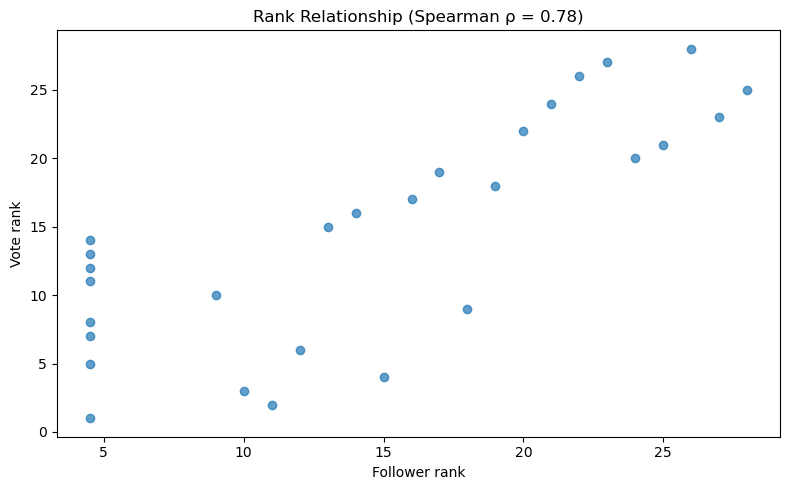

In [4]:
from scipy.stats import spearmanr

df['rank_votes'] = df['votes'].rank()
df['rank_followers'] = df['followers'].rank()

rho, p = spearmanr(df['rank_votes'], df['rank_followers'])

plt.figure(figsize=(8,5))
plt.scatter(df['rank_followers'], df['rank_votes'], alpha=0.7)
plt.xlabel("Follower rank")
plt.ylabel("Vote rank")
plt.title(f"Rank Relationship (Spearman ρ = {rho:.2f})")
plt.tight_layout()
plt.savefig("latex/rank_followers_votes.pgf")
plt.show()


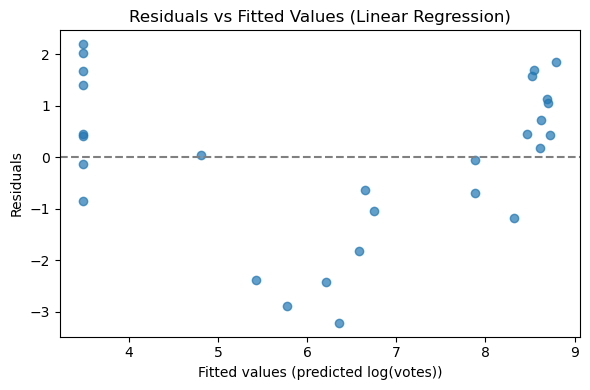

In [5]:
import matplotlib.pyplot as plt

# Fit linear regression (log-log model example)
y_true = y2           # log(votes + 1)
y_pred = m2.predict(X2)

residuals = y_true - y_pred

plt.figure(figsize=(6, 4))
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(0, linestyle="--", color="gray")

plt.xlabel("Fitted values (predicted log(votes))")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values (Linear Regression)")
plt.tight_layout()
plt.show()


In [6]:
import matplotlib.pyplot as plt

cv_scores = cv_scores_model2  # your cross_val_score output

plt.figure(figsize=(6, 4))
plt.bar(range(len(cv_scores)), cv_scores)
plt.axhline(0, linestyle="--", color="gray")

plt.xlabel("CV fold")
plt.ylabel("R²")
plt.title("Cross-Validated R² (Linear Regression)")
plt.tight_layout()
plt.show()


NameError: name 'cv_scores_model2' is not defined

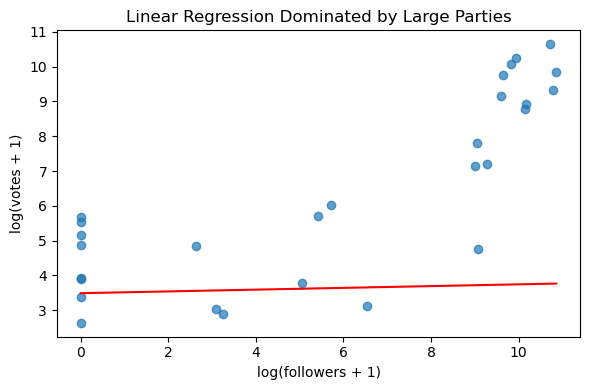

In [7]:
plt.figure(figsize=(6, 4))
plt.scatter(df["log_followers"], df["log_votes"], alpha=0.7)

# regression line
x_vals = np.linspace(df["log_followers"].min(), df["log_followers"].max(), 100)
y_vals = m2.intercept_ + m2.coef_[0] * x_vals
plt.plot(x_vals, y_vals, color="red")

plt.xlabel("log(followers + 1)")
plt.ylabel("log(votes + 1)")
plt.title("Linear Regression Dominated by Large Parties")
plt.tight_layout()
plt.show()
